# Analyzing Network Topology

## Initialization: loading the graph

In [4]:
import json
import networkx as nx

# JSON file path
json_file = "project/file/graph_networkx_15_nodes.json"

# Loading the topology
with open(json_file, "r") as f:
    data = json.load(f)

# Creating the graph in NetworkX
G = nx.Graph()

# Adding nodes with IDs and attributes
for node in data["nodes"]:
    node_id = node["id"]        
    attrs = {k: v for k, v in node.items() if k != "id"} 
    G.add_node(node_id, **attrs)

# Adding edges with attributes
for edge in data["links"]:
    src = edge["source"]
    dst = edge["target"]
    attrs = {k: v for k, v in edge.items() if k not in ["source", "target"]}
    G.add_edge(src, dst, **attrs)

print("Graph loaded correctly!")
print(f"Nodes: {G.nodes(data=True)}")
print(f"Edges: {G.edges(data=True)}")

Graph loaded correctly!
Nodes: [(0, {'type': 'T'}), (1, {'type': 'T'}), (2, {'type': 'T'}), (3, {'type': 'T'}), (4, {'type': 'M', 'peers': 0}), (5, {'type': 'M', 'peers': 0}), (6, {'type': 'CP', 'peers': 0}), (7, {'type': 'C', 'peers': 0}), (8, {'type': 'C', 'peers': 0}), (9, {'type': 'C', 'peers': 0}), (10, {'type': 'C', 'peers': 0}), (11, {'type': 'C', 'peers': 0}), (12, {'type': 'C', 'peers': 0}), (13, {'type': 'C', 'peers': 0}), (14, {'type': 'C', 'peers': 0})]
Edges: [(0, 1, {'type': 'peer', 'customer': 'none'}), (0, 2, {'type': 'peer', 'customer': 'none'}), (0, 3, {'type': 'peer', 'customer': 'none'}), (0, 4, {'type': 'transit', 'customer': '4'}), (0, 12, {'type': 'transit', 'customer': '12'}), (1, 2, {'type': 'peer', 'customer': 'none'}), (1, 3, {'type': 'peer', 'customer': 'none'}), (2, 3, {'type': 'peer', 'customer': 'none'}), (2, 5, {'type': 'transit', 'customer': '5'}), (2, 8, {'type': 'transit', 'customer': '8'}), (2, 9, {'type': 'transit', 'customer': '9'}), (3, 4, {'type'

## Graph Visualization

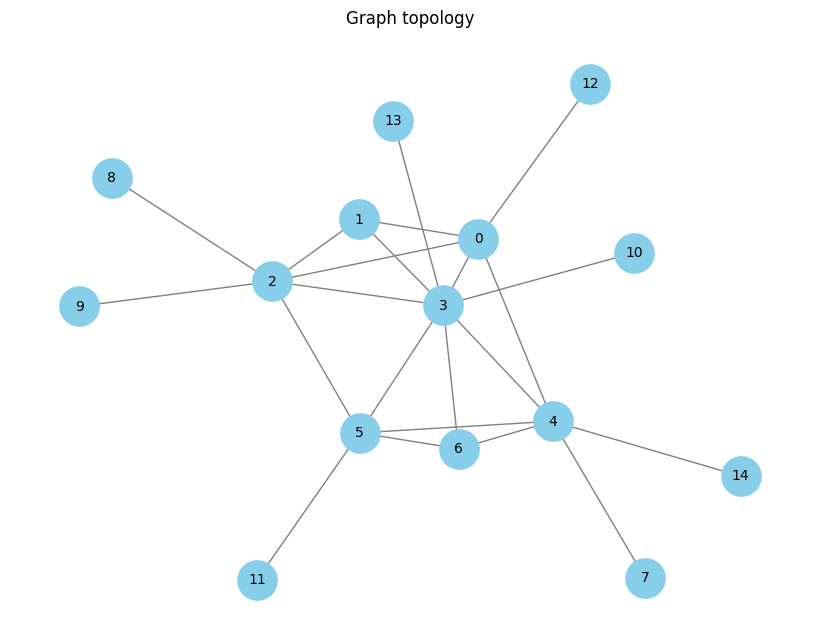

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G, pos,
    with_labels=True,
    node_size=800,
    node_color="skyblue",
    edge_color="gray",
    font_size=10
)
plt.title("Graph topology")
plt.show()

## Computing Shortest Paths

In [6]:
all_shortest_paths = dict(nx.all_pairs_shortest_path(G))

## Printing Shortest Paths for a specific node

In [9]:
source_node = 0

if source_node in all_shortest_paths:
    print(f"Shortest path from node {source_node}:")
    for target, path in all_shortest_paths[source_node].items():
        print(f"  -> {target}: {path}")
else:
    print(f"{source_node} node does not exist in the graph!")

Shortest path from node 0:
  -> 0: [0]
  -> 1: [0, 1]
  -> 2: [0, 2]
  -> 3: [0, 3]
  -> 4: [0, 4]
  -> 12: [0, 12]
  -> 5: [0, 2, 5]
  -> 8: [0, 2, 8]
  -> 9: [0, 2, 9]
  -> 6: [0, 3, 6]
  -> 10: [0, 3, 10]
  -> 13: [0, 3, 13]
  -> 7: [0, 4, 7]
  -> 14: [0, 4, 14]
  -> 11: [0, 2, 5, 11]


## Computing Centrality

In [10]:
centrality = nx.betweenness_centrality(G)

print("Centrality values:")
for node, value in centrality.items():
    print(f"{node}: {value:.4f}")

Centrality values:
0: 0.1923
1: 0.0000
2: 0.3004
3: 0.3883
4: 0.3004
5: 0.1923
6: 0.0000
7: 0.0000
8: 0.0000
9: 0.0000
10: 0.0000
11: 0.0000
12: 0.0000
13: 0.0000
14: 0.0000


## Ordering Nodes for Centrality Value (descending order)

In [11]:
sorted_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)

print("Nodes ordered for descending centrality:")
for node, value in sorted_nodes:
    print(f"{node}: {value:.4f}")

Nodes ordered for descending centrality:
3: 0.3883
2: 0.3004
4: 0.3004
0: 0.1923
5: 0.1923
1: 0.0000
6: 0.0000
7: 0.0000
8: 0.0000
9: 0.0000
10: 0.0000
11: 0.0000
12: 0.0000
13: 0.0000
14: 0.0000


## Highlighting Most Central Nodes

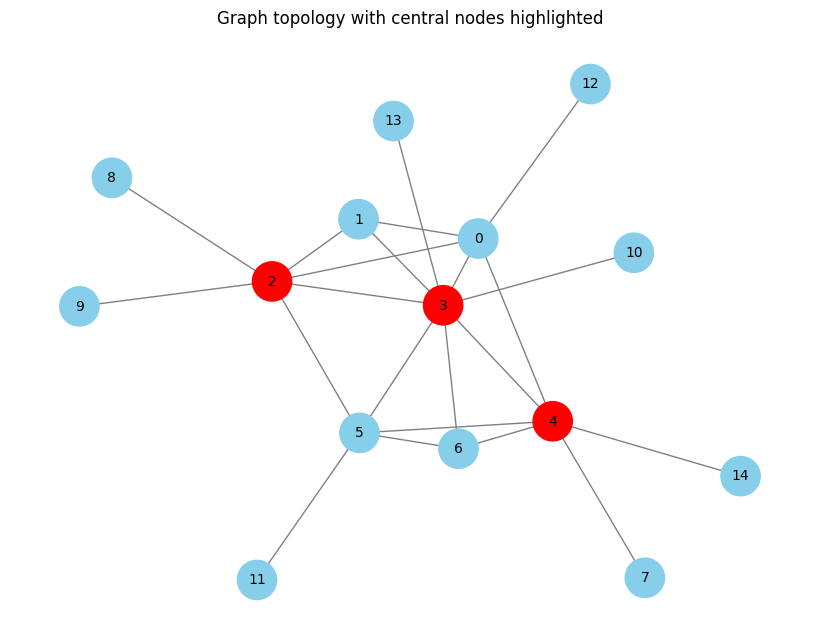

In [12]:
# Central nodes are red coloured
central_nodes = set([node for node, _ in sorted_nodes[:3]])
node_colors = ["red" if n in central_nodes else "skyblue" for n in G.nodes()]

plt.figure(figsize=(8,6))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=800,
    node_color=node_colors,
    edge_color="gray",
    font_size=10
)
plt.title("Graph topology with central nodes highlighted")
plt.show()

## Shortest Paths avoiding nodes with higher centrality values

In [13]:
# Number of nodes with high centrality value to avoid
top_k = 1
nodes_to_avoid = [node for node, _ in sorted_nodes[:top_k]]

print(f"Nodes to avoid: {nodes_to_avoid}")

# New graph without these nodes
G_reduced = G.copy()
G_reduced.remove_nodes_from(nodes_to_avoid)

# Compute shortest paths again
reduced_paths = dict(nx.all_pairs_shortest_path(G_reduced))

if source_node in reduced_paths:
    print(f"New shortest paths from node {source_node} avoiding most central nodes:")
    for target, path in reduced_paths[source_node].items():
        print(f"  -> {target}: {path}")
else:
    print(f"{source_node} node does not exist in the graph!")

Nodes to avoid: [3]
New shortest paths from node 0 avoiding most central nodes:
  -> 0: [0]
  -> 1: [0, 1]
  -> 2: [0, 2]
  -> 4: [0, 4]
  -> 12: [0, 12]
  -> 5: [0, 2, 5]
  -> 8: [0, 2, 8]
  -> 9: [0, 2, 9]
  -> 6: [0, 4, 6]
  -> 7: [0, 4, 7]
  -> 14: [0, 4, 14]
  -> 11: [0, 2, 5, 11]


## Centrality values as node weights

In [ ]:
import math

# New weighted graph
G_weighted = nx.Graph()

for u, v in G.edges():
    # weight = average centrality of the two nodes + 1 to avoid 0 values
    weight = (centrality[u] + centrality[v]) / 2 + 1
    G_weighted.add_edge(u, v, weight=weight)

# Shortest paths computation on weighted graph on single source node
weighted_paths = nx.single_source_dijkstra_path(G_weighted, source_node, weight="weight")

print(f"Shortest paths from node {source_node} minimizing centrality values:")
for target, path in weighted_paths.items():
    print(f"  -> {target}: {path}")

# Shortest paths computation on weighted graph for all nodes
all_weighted_paths = dict(nx.all_pairs_dijkstra_path(G, weight="weight"))

# print("Shortest paths for all node pairs:")
# for source, targets in all_weighted_paths.items():
#     for target, path in targets.items():
#         print(f"{source} -> {target}: {path}")

Shortest paths from node 0 minimizing centrality values:
  -> 0: [0]
  -> 1: [0, 1]
  -> 2: [0, 2]
  -> 3: [0, 3]
  -> 4: [0, 4]
  -> 12: [0, 12]
  -> 5: [0, 2, 5]
  -> 8: [0, 2, 8]
  -> 9: [0, 2, 9]
  -> 6: [0, 4, 6]
  -> 7: [0, 4, 7]
  -> 14: [0, 4, 14]
  -> 10: [0, 3, 10]
  -> 13: [0, 3, 13]
  -> 11: [0, 2, 5, 11]


'\nprint("Cammini minimi pesati tra tutte le coppie di nodi:")\nfor source, targets in all_weighted_paths.items():\n    for target, path in targets.items():\n        print(f"{source} -> {target}: {path}")\n\n'